In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
#load the saved datasets
train_df = pd.read_csv("../data/splits/train.csv")
test_df = pd.read_csv("../data/splits/test.csv")

print("Training shape:", train_df.shape)
print("Testing shape:", test_df.shape)

Training shape: (13070, 2)
Testing shape: (3268, 2)


In [8]:
#prepare x and y
X_train = train_df["text"]
y_train = train_df["queue"]

X_test = test_df["text"]
y_test = test_df["queue"]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("Number of queues:", y_train.nunique())

#classes
print(sorted(y_train.unique()))

Training samples: 13070
Testing samples: 3268
Number of queues: 10
['Billing and Payments', 'Customer Service', 'General Inquiry', 'Human Resources', 'IT Support', 'Product Support', 'Returns and Exchanges', 'Sales and Pre-Sales', 'Service Outages and Maintenance', 'Technical Support']


In [11]:
#Load the TF-IDF vectorizer
tfidf = joblib.load(
    "../models/tfidf_vectorizer.pkl"
)
print("TF-IDF vectorizer loaded.")

X_train_tfidf = tfidf.transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

TF-IDF vectorizer loaded.
Training TF-IDF shape: (13070, 46423)
Testing TF-IDF shape: (3268, 46423)


In [50]:
#train linear svm 
#linearsvc for text classification
svm_model = LinearSVC(
    class_weight="balanced",
    C=1.0,
    random_state=42
)
svm_model.fit(
    X_train_tfidf,
    y_train
)
y_pred = svm_model.predict(X_test_tfidf)
print("Linear SVM training completed.")

Linear SVM training completed.


In [16]:
#generate predictoions
y_pred_svm = svm_model.predict(
    X_test_tfidf
)
print("SVM predictions generated.")


comparison = pd.DataFrame({
    "actual": y_test.values[:10],
    "predicted": y_pred_svm[:10]
})

comparison

SVM predictions generated.


,actual,predicted
0,Technical Support,Product Support
1,Technical Support,Technical Support
2,Technical Support,Technical Support
3,IT Support,IT Support
4,Technical Support,Technical Support
5,General Inquiry,Product Support
6,Product Support,Product Support
7,Product Support,Technical Support
8,Technical Support,Technical Support
9,Technical Support,Technical Support


In [17]:
#metrics
svm_accuracy = accuracy_score(
    y_test,
    y_pred_svm
)

svm_precision = precision_score(
    y_test,
    y_pred_svm,
    average="weighted",
    zero_division=0
)

svm_recall = recall_score(
    y_test,
    y_pred_svm,
    average="weighted",
    zero_division=0
)

svm_f1 = f1_score(
    y_test,
    y_pred_svm,
    average="weighted",
    zero_division=0
)

print(f"Accuracy : {svm_accuracy:.4f}")
print(f"Precision: {svm_precision:.4f}")
print(f"Recall   : {svm_recall:.4f}")
print(f"F1-score : {svm_f1:.4f}")

Accuracy : 0.6845
Precision: 0.6845
Recall   : 0.6845
F1-score : 0.6840


In [27]:
svm_report = classification_report(
    y_test,
    y_pred_svm,
    zero_division=0
)
print(svm_report)

                                 precision    recall  f1-score   support

           Billing and Payments       0.84      0.87      0.86       319
               Customer Service       0.63      0.65      0.64       482
                General Inquiry       0.82      0.68      0.74        47
                Human Resources       0.77      0.69      0.73        70
                     IT Support       0.60      0.61      0.60       388
                Product Support       0.66      0.63      0.64       615
          Returns and Exchanges       0.69      0.64      0.66       164
            Sales and Pre-Sales       0.62      0.67      0.64       103
Service Outages and Maintenance       0.71      0.82      0.76       133
              Technical Support       0.70      0.70      0.70       947

                       accuracy                           0.68      3268
                      macro avg       0.70      0.69      0.70      3268
                   weighted avg       0.68      0

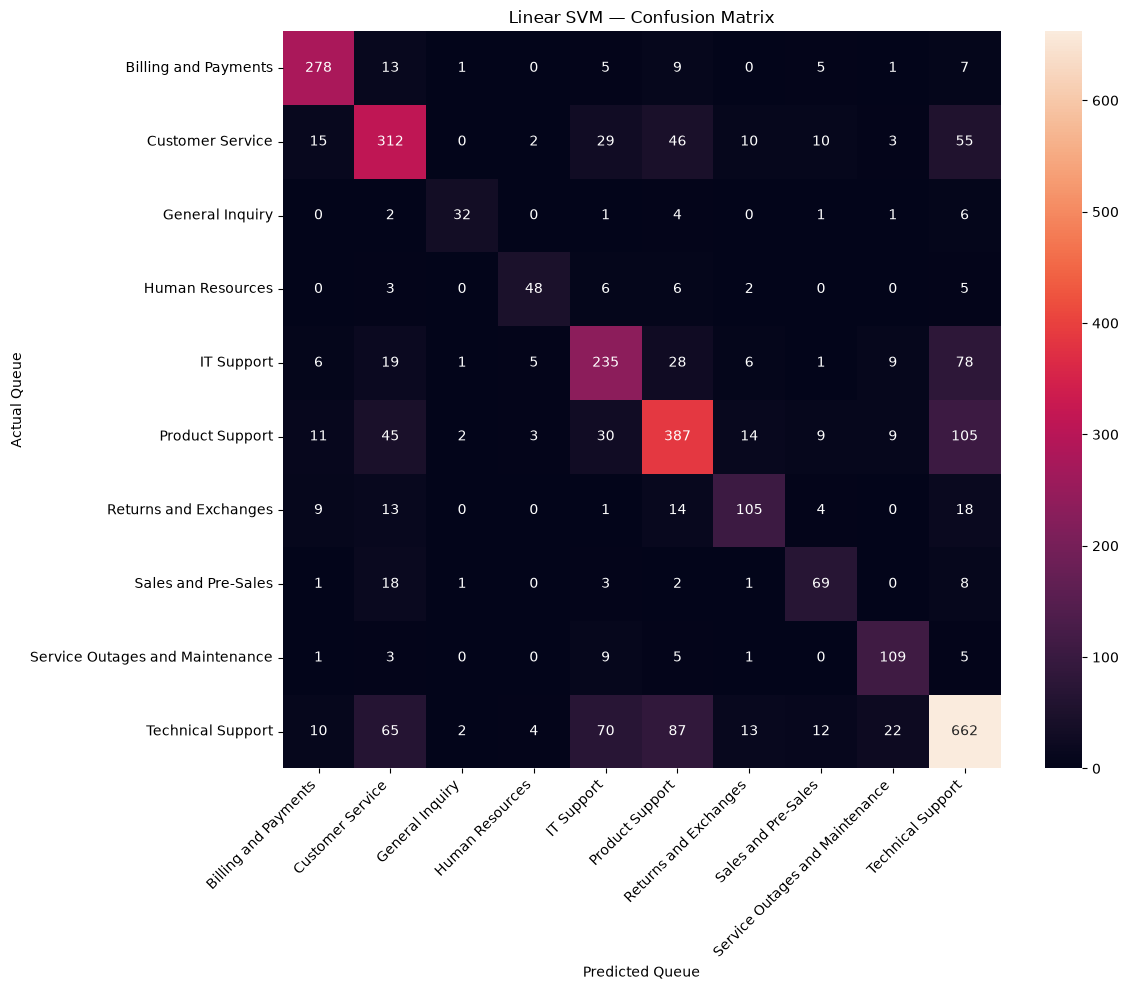

In [28]:
#confusion matrix
svm_cm = confusion_matrix(
    y_test,
    y_pred_svm,
    labels=svm_model.classes_
)

plt.figure(figsize=(12, 10))

sns.heatmap(
    svm_cm,
    annot=True,
    fmt="d",
    xticklabels=svm_model.classes_,
    yticklabels=svm_model.classes_
)

plt.title("Linear SVM — Confusion Matrix")
plt.xlabel("Predicted Queue")
plt.ylabel("Actual Queue")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [37]:
#Compare Logistic Regression vs SVM
logistic_results = pd.read_csv(
    "../reports/model_results.csv"
)
logistic_results
svm_results = pd.DataFrame([{
    "model": "Linear SVM",
    "features": "TF-IDF",
    "accuracy": svm_accuracy,
    "precision_weighted": svm_precision,
    "recall_weighted": svm_recall,
    "f1_weighted": svm_f1
}])
svm_results


,model,features,accuracy,precision_weighted,recall_weighted,f1_weighted
0,Linear SVM,TF-IDF,0.684517,0.684499,0.684517,0.684012


In [ ]:

model_comparison = pd.concat(
    [
        logistic_results,
        svm_results
    ],
    ignore_index=True
)
model_comparison

,model,features,accuracy,precision_weighted,recall_weighted,f1_weighted
0,Logistic Regression,TF-IDF,0.529376,0.542413,0.529376,0.530569
1,Linear SVM,TF-IDF,0.684517,0.684499,0.684517,0.684012


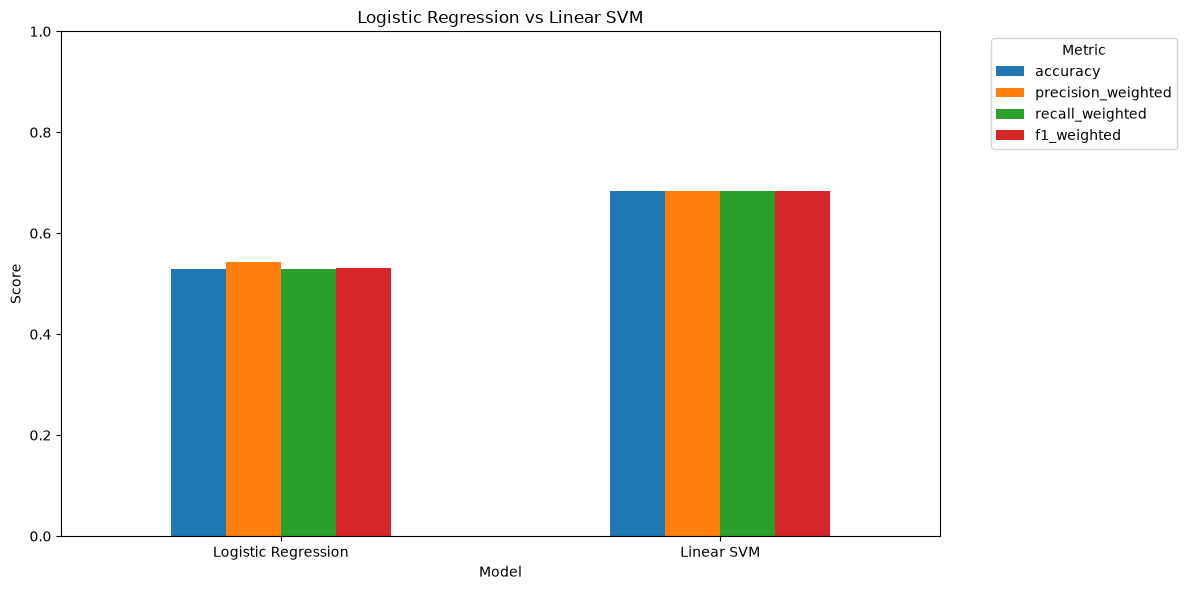

In [39]:
metrics = [
    "accuracy",
    "precision_weighted",
    "recall_weighted",
    "f1_weighted"
]
comparison_plot = model_comparison.set_index("model")[metrics]
comparison_plot.plot(
    kind="bar",
    figsize=(12, 6)
)
plt.title("Logistic Regression vs Linear SVM")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1)

plt.xticks(rotation=0)
plt.legend(
    title="Metric",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()

In [41]:
#Save combined results
os.makedirs("../reports", exist_ok=True)

model_comparison.to_csv(
    "../reports/model_comparison.csv",
    index=False
)

print("Model comparison saved.")

Model comparison saved.


Identify the better-performing model

In [47]:
best_by_f1 = model_comparison.loc[
    model_comparison["f1_weighted"].idxmax()
]
print("Highest weighted F1:")
print(best_by_f1)

Highest weighted F1:
model                 Linear SVM
features                  TF-IDF
accuracy                0.684517
precision_weighted      0.684499
recall_weighted         0.684517
f1_weighted             0.684012
Name: 1, dtype: object


In [46]:
best_by_accuracy = model_comparison.loc[
    model_comparison["accuracy"].idxmax()
]
print("\nHighest accuracy:")
print(best_by_accuracy)


Highest accuracy:
model                 Linear SVM
features                  TF-IDF
accuracy                0.684517
precision_weighted      0.684499
recall_weighted         0.684517
f1_weighted             0.684012
Name: 1, dtype: object


In [49]:
selected_model = best_by_f1["model"]

selection_info = pd.DataFrame([{
    "selection_metric": "weighted_f1",
    "selected_model": selected_model
}])

selection_info.to_csv(
    "../reports/selected_model.csv",
    index=False
)
print("Selected model based on weighted F1:", selected_model)

Selected model based on weighted F1: Linear SVM


#TESTTTTTTTTTTTT!!!!



In [ ]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(
    C=1.0,
    class_weight="balanced",
    random_state=42
)

svm_model.fit(X_train_tfidf, y_train)

y_pred = svm_model.predict(X_test_tfidf)

In [53]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import LinearSVC

param_grid = {
    "C": [0.1, 0.5, 1, 2, 5, 10]
}

grid = GridSearchCV(
    LinearSVC(
        class_weight="balanced",
        random_state=42
    ),
    param_grid,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1
)

grid.fit(X_train_tfidf, y_train)

print("Best parameters:", grid.best_params_)
print("Best CV Macro F1:", grid.best_score_)

Best parameters: {'C': 10}
Best CV Macro F1: 0.6954895415794887


In [54]:
best_svm = grid.best_estimator_
y_pred = best_svm.predict(X_test_tfidf)

In [56]:
word_tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

char_tfidf = TfidfVectorizer(
    analyzer="char",
    ngram_range=(3, 5),
    min_df=2,
    max_features=100000
)

In [59]:
from sklearn.feature_extraction.text import TfidfVectorizer

word_tfidf = TfidfVectorizer(
    lowercase=True,
    strip_accents="unicode",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    max_features=100000
)

X_train_word = word_tfidf.fit_transform(X_train)
X_test_word = word_tfidf.transform(X_test)

print("Word TF-IDF:")
print("Train:", X_train_word.shape)
print("Test :", X_test_word.shape)

Word TF-IDF:
Train: (13070, 46423)
Test : (3268, 46423)


TfIDF EXPERIMENTS


In [61]:
#Experiment 1 — Word TF-IDF: Unigrams (1,1)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

word_tfidf_11 = TfidfVectorizer(
    lowercase=True,
    strip_accents="unicode",
    ngram_range=(1, 1),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_11 = word_tfidf_11.fit_transform(X_train)
X_test_11 = word_tfidf_11.transform(X_test)

print("Training shape:", X_train_11.shape)
print("Testing shape:", X_test_11.shape)

Training shape: (13070, 4116)
Testing shape: (3268, 4116)


In [63]:
svm_11 = LinearSVC(
    C=10,
    class_weight="balanced"
)

svm_11.fit(X_train_11, y_train)

pred_11 = svm_11.predict(X_test_11)

In [64]:
results_11 = {
    "Model": "SVM + Word TF-IDF (1,1)",
    "Accuracy": accuracy_score(y_test, pred_11),
    "Precision": precision_score(y_test, pred_11, average="weighted", zero_division=0),
    "Recall": recall_score(y_test, pred_11, average="weighted", zero_division=0),
    "Macro F1": f1_score(y_test, pred_11, average="macro", zero_division=0),
    "Weighted F1": f1_score(y_test, pred_11, average="weighted", zero_division=0)
}

results_11

{'Model': 'SVM + Word TF-IDF (1,1)',
 'Accuracy': 0.5370257037943696,
 'Precision': 0.545788003044876,
 'Recall': 0.5370257037943696,
 'Macro F1': 0.5407360970903459,
 'Weighted F1': 0.5380403041275399}

EXP 2


In [66]:
word_tfidf_12 = TfidfVectorizer(
    lowercase=True,
    strip_accents="unicode",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_12 = word_tfidf_12.fit_transform(X_train)
X_test_12 = word_tfidf_12.transform(X_test)

print("Training shape:", X_train_12.shape)
print("Testing shape:", X_test_12.shape)

Training shape: (13070, 46423)
Testing shape: (3268, 46423)


In [68]:
svm_12 = LinearSVC(
    C=10,
    class_weight="balanced"
)

svm_12.fit(X_train_12, y_train)

pred_12 = svm_12.predict(X_test_12)

In [69]:
results_12 = {
    "Model": "SVM + Word TF-IDF (1,2)",
    "Accuracy": accuracy_score(y_test, pred_12),
    "Precision": precision_score(y_test, pred_12, average="weighted", zero_division=0),
    "Recall": recall_score(y_test, pred_12, average="weighted", zero_division=0),
    "Macro F1": f1_score(y_test, pred_12, average="macro", zero_division=0),
    "Weighted F1": f1_score(y_test, pred_12, average="weighted", zero_division=0)
}

results_12

{'Model': 'SVM + Word TF-IDF (1,2)',
 'Accuracy': 0.7123623011015912,
 'Precision': 0.7149858607998885,
 'Recall': 0.7123623011015912,
 'Macro F1': 0.7242238224987554,
 'Weighted F1': 0.7121187522525219}

EXP 3


In [70]:
word_tfidf_13 = TfidfVectorizer(
    lowercase=True,
    strip_accents="unicode",
    ngram_range=(1, 3),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_13 = word_tfidf_13.fit_transform(X_train)
X_test_13 = word_tfidf_13.transform(X_test)

print("Training shape:", X_train_13.shape)
print("Testing shape:", X_test_13.shape)

Training shape: (13070, 129864)
Testing shape: (3268, 129864)


In [71]:
svm_13 = LinearSVC(
    C=10,
    class_weight="balanced"
)

svm_13.fit(X_train_13, y_train)

pred_13 = svm_13.predict(X_test_13)

In [72]:
results_13 = {
    "Model": "SVM + Word TF-IDF (1,3)",
    "Accuracy": accuracy_score(y_test, pred_13),
    "Precision": precision_score(y_test, pred_13, average="weighted", zero_division=0),
    "Recall": recall_score(y_test, pred_13, average="weighted", zero_division=0),
    "Macro F1": f1_score(y_test, pred_13, average="macro", zero_division=0),
    "Weighted F1": f1_score(y_test, pred_13, average="weighted", zero_division=0)
}

results_13

{'Model': 'SVM + Word TF-IDF (1,3)',
 'Accuracy': 0.7383720930232558,
 'Precision': 0.7432618780399021,
 'Recall': 0.7383720930232558,
 'Macro F1': 0.7519391354049358,
 'Weighted F1': 0.7380406465603003}

EXP 4


In [73]:
char_tfidf = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3, 5),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_char = char_tfidf.fit_transform(X_train)
X_test_char = char_tfidf.transform(X_test)

print("Training shape:", X_train_char.shape)
print("Testing shape:", X_test_char.shape)

Training shape: (13070, 29422)
Testing shape: (3268, 29422)


In [74]:
svm_char = LinearSVC(
    C=10,
    class_weight="balanced"
)

svm_char.fit(X_train_char, y_train)

pred_char = svm_char.predict(X_test_char)

c:\Users\Akshada\.vscode\Adaptive_Ticket_Routing\.venv\Lib\site-packages\sklearn\svm\_base.py:1295: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [75]:
results_char = {
    "Model": "SVM + Character TF-IDF (3,5)",
    "Accuracy": accuracy_score(y_test, pred_char),
    "Precision": precision_score(y_test, pred_char, average="weighted", zero_division=0),
    "Recall": recall_score(y_test, pred_char, average="weighted", zero_division=0),
    "Macro F1": f1_score(y_test, pred_char, average="macro", zero_division=0),
    "Weighted F1": f1_score(y_test, pred_char, average="weighted", zero_division=0)
}

results_char

{'Model': 'SVM + Character TF-IDF (3,5)',
 'Accuracy': 0.5768053855569155,
 'Precision': 0.5833247384082926,
 'Recall': 0.5768053855569155,
 'Macro F1': 0.5737485826237579,
 'Weighted F1': 0.5773031482731075}

EXP 5


In [76]:
from scipy.sparse import hstack

X_train_combined = hstack([
    X_train_12,
    X_train_char
])

X_test_combined = hstack([
    X_test_12,
    X_test_char
])

print("Combined training shape:", X_train_combined.shape)
print("Combined testing shape:", X_test_combined.shape)

Combined training shape: (13070, 75845)
Combined testing shape: (3268, 75845)


In [77]:
svm_combined = LinearSVC(
    C=10,
    class_weight="balanced"
)
svm_combined.fit(X_train_combined, y_train)
pred_combined = svm_combined.predict(X_test_combined)

In [78]:
results_combined = {
    "Model": "SVM + Word (1,2) + Character TF-IDF",
    "Accuracy": accuracy_score(y_test, pred_combined),
    "Precision": precision_score(y_test, pred_combined, average="weighted", zero_division=0),
    "Recall": recall_score(y_test, pred_combined, average="weighted", zero_division=0),
    "Macro F1": f1_score(y_test, pred_combined, average="macro", zero_division=0),
    "Weighted F1": f1_score(y_test, pred_combined, average="weighted", zero_division=0)
}
results_combined

{'Model': 'SVM + Word (1,2) + Character TF-IDF',
 'Accuracy': 0.7166462668298653,
 'Precision': 0.7188238610494542,
 'Recall': 0.7166462668298653,
 'Macro F1': 0.7195081948416651,
 'Weighted F1': 0.7163970974786051}

Compare



In [79]:
results = pd.DataFrame([
    results_11,
    results_12,
    results_13,
    results_char,
    results_combined
])

results

,Model,Accuracy,Precision,Recall,Macro F1,Weighted F1
0,"SVM + Word TF-IDF (1,1)",0.537026,0.545788,0.537026,0.540736,0.538040
1,"SVM + Word TF-IDF (1,2)",0.712362,0.714986,0.712362,0.724224,0.712119
2,"SVM + Word TF-IDF (1,3)",0.738372,0.743262,0.738372,0.751939,0.738041
3,"SVM + Character TF-IDF (3,5)",0.576805,0.583325,0.576805,0.573749,0.577303
4,"SVM + Word (1,2) + Character TF-IDF",0.716646,0.718824,0.716646,0.719508,0.716397


In [80]:
results.sort_values(
    by="Macro F1",
    ascending=False
).reset_index(drop=True)

,Model,Accuracy,Precision,Recall,Macro F1,Weighted F1
0,"SVM + Word TF-IDF (1,3)",0.738372,0.743262,0.738372,0.751939,0.738041
1,"SVM + Word TF-IDF (1,2)",0.712362,0.714986,0.712362,0.724224,0.712119
2,"SVM + Word (1,2) + Character TF-IDF",0.716646,0.718824,0.716646,0.719508,0.716397
3,"SVM + Character TF-IDF (3,5)",0.576805,0.583325,0.576805,0.573749,0.577303
4,"SVM + Word TF-IDF (1,1)",0.537026,0.545788,0.537026,0.540736,0.538040


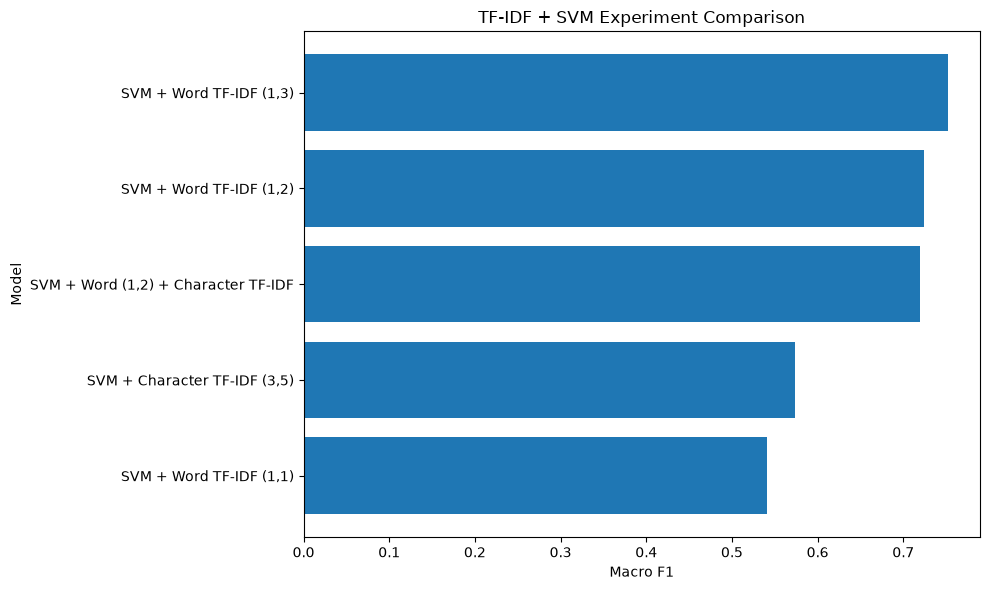

In [81]:
results_plot = results.sort_values("Macro F1")

plt.figure(figsize=(10, 6))

plt.barh(
    results_plot["Model"],
    results_plot["Macro F1"]
)

plt.xlabel("Macro F1")
plt.ylabel("Model")
plt.title("TF-IDF + SVM Experiment Comparison")

plt.tight_layout()
plt.show()

In [83]:
results.to_csv(
    "../reports/tfidf_svm_experiments.csv",
    index=False
)

print("Experiment results saved successfully.")

Experiment results saved successfully.


In [84]:
#save best model
best_tfidf = TfidfVectorizer(
    lowercase=True,
    strip_accents="unicode",
    ngram_range=(1, 3),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_best = best_tfidf.fit_transform(X_train)
X_test_best = best_tfidf.transform(X_test)

In [85]:
from sklearn.svm import LinearSVC

best_svm = LinearSVC(
    C=10,
    class_weight="balanced"
)

best_svm.fit(X_train_best, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo

In [86]:
best_pred = best_svm.predict(X_test_best)

print(classification_report(
    y_test,
    best_pred,
    zero_division=0
))

                                 precision    recall  f1-score   support

           Billing and Payments       0.88      0.89      0.89       319
               Customer Service       0.68      0.71      0.70       482
                General Inquiry       0.91      0.64      0.75        47
                Human Resources       0.96      0.70      0.81        70
                     IT Support       0.72      0.63      0.67       388
                Product Support       0.69      0.71      0.70       615
          Returns and Exchanges       0.85      0.63      0.73       164
            Sales and Pre-Sales       0.80      0.66      0.72       103
Service Outages and Maintenance       0.81      0.80      0.80       133
              Technical Support       0.71      0.79      0.75       947

                       accuracy                           0.74      3268
                      macro avg       0.80      0.72      0.75      3268
                   weighted avg       0.74      0

In [87]:
joblib.dump(
    best_tfidf,
    "../models/best_tfidf_vectorizer.pkl"
)

joblib.dump(
    best_svm,
    "../models/best_svm_model.pkl"
)

print("Best TF-IDF vectorizer saved.")
print("Best SVM model saved.")


Best TF-IDF vectorizer saved.
Best SVM model saved.


In [89]:
results.to_csv(
    "../reports/model_comparison.csv",
    index=False
)

print("Model comparison saved.")

Model comparison saved.


In [91]:
#save classification report
from sklearn.metrics import classification_report

final_report = classification_report(
    y_test,
    best_pred,
    zero_division=0
)

print(final_report)

                                 precision    recall  f1-score   support

           Billing and Payments       0.88      0.89      0.89       319
               Customer Service       0.68      0.71      0.70       482
                General Inquiry       0.91      0.64      0.75        47
                Human Resources       0.96      0.70      0.81        70
                     IT Support       0.72      0.63      0.67       388
                Product Support       0.69      0.71      0.70       615
          Returns and Exchanges       0.85      0.63      0.73       164
            Sales and Pre-Sales       0.80      0.66      0.72       103
Service Outages and Maintenance       0.81      0.80      0.80       133
              Technical Support       0.71      0.79      0.75       947

                       accuracy                           0.74      3268
                      macro avg       0.80      0.72      0.75      3268
                   weighted avg       0.74      0

In [92]:
with open("../reports/classification_report.txt", "w", encoding="utf-8") as f:
    f.write("Final SVM Classification Report\n")
    f.write("=" * 50 + "\n\n")
    f.write(final_report)

print("Classification report saved.")

Classification report saved.


In [95]:
final_results = f"""
FINAL PERSON 1 MODEL RESULTS
============================

Final Model:
SVM + Word TF-IDF (1,3)

Task:
Customer Support Ticket Queue Classification

Number of Classes:
{y_test.nunique()}

Accuracy:
{accuracy_score(y_test, best_pred):.4f}

Weighted Precision:
{precision_score(y_test, best_pred, average="weighted", zero_division=0):.4f}

Weighted Recall:
{recall_score(y_test, best_pred, average="weighted", zero_division=0):.4f}

Macro F1:
{f1_score(y_test, best_pred, average="macro", zero_division=0):.4f}

Weighted F1:
{f1_score(y_test, best_pred, average="weighted", zero_division=0):.4f}

Unknown Ticket Detection:
Implemented using prediction confidence/margin thresholding.

Final routing behavior:
High-confidence prediction -> KNOWN / ROUTE
Low-confidence prediction -> UNKNOWN / REVIEW
"""

print(final_results)

with open("../reports/final_results.txt", "w", encoding="utf-8") as f:
    f.write(final_results)

print("Final results saved.")


FINAL PERSON 1 MODEL RESULTS

Final Model:
SVM + Word TF-IDF (1,3)

Task:
Customer Support Ticket Queue Classification

Number of Classes:
10

Accuracy:
0.7384

Weighted Precision:
0.7433

Weighted Recall:
0.7384

Macro F1:
0.7519

Weighted F1:
0.7380

Unknown Ticket Detection:
Implemented using prediction confidence/margin thresholding.

Final routing behavior:
High-confidence prediction -> KNOWN / ROUTE
Low-confidence prediction -> UNKNOWN / REVIEW

Final results saved.


Final Model:
SVM + Word TF-IDF (1,3)

Accuracy: 73.84%
Precision: 74.33%
Recall: 73.84%
Macro F1: 75.19%
Weighted F1: 73.80%


Among the tested TF-IDF configurations, SVM with word-level TF-IDF using 1–3 gram features achieved the strongest overall performance and was selected as the final ticket-routing classifier.